<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Bet Sizing: Closed-Form OU Rules
    </h1>
  </div>
</div>

For a mean-reverting (Ornstein-Uhlenbeck) signal, de Prado sizes a bet by a
**Monte-Carlo grid**: simulate many OU paths and, for each profit-take / stop-loss
pair on a grid, score the realized trades and pick the grid argmax (AFML ch.13).
That grid carries simulation noise, costs compute, and is limited by its resolution.

The **Lipton-Lopez de Prado (2020) closed form** gives the exact optimal thresholds
from first-passage theory: the probability of hitting the profit barrier before the
stop, and the mean first-exit time, both in closed form, so the objective (expected
net return per unit time) is optimized with no simulation noise and negligible
compute. We reproduce the grid, then show the closed form lands at the same optimum
far faster.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# --- Local source bootstrap -------------------------------------------------
# The admitted Stage-1 methods demonstrated here are merged in the RiskLabAI.py
# source tree but not yet in a tagged PyPI release, so we put the local source
# ahead of any installed copy. Once these ship in a release this block is a
# no-op and a plain `pip install RiskLabAI` is enough.
import sys
from pathlib import Path
_cands = [p / "RiskLabAI.py" for p in [Path.cwd(), *Path.cwd().parents]]
_cands.append(Path(r"C:/risklab/risklabai/RiskLabAI.py"))
for _src in _cands:
    if (_src / "RiskLabAI" / "__init__.py").exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})


In [2]:
from RiskLabAI.backtest.ou_trading_rules import (
    optimal_ou_trading_rule,   # closed-form optimal profit-take / stop-loss
    theta_from_half_life,      # OU mean-reversion speed from a half-life
)
import time

# OU deviation Y: dY = -theta*Y dt + sigma dW, entered at y0 = -entry_gap.
THETA = theta_from_half_life(10.0)   # 10-step mean-reversion half-life
SIGMA, ENTRY_GAP, COST, DT = 0.25, 1.0, 0.10, 1.0
print(f"OU parameters: theta={THETA:.4f} (half-life 10), sigma={SIGMA}, "
      f"entry_gap={ENTRY_GAP}, cost={COST}")

OU parameters: theta=0.0693 (half-life 10), sigma=0.25, entry_gap=1.0, cost=0.1


## 1. The Monte-Carlo PT/SL grid (de Prado baseline)

We simulate OU paths and evaluate the **expected net return per unit time** for each
profit-take / stop-loss pair on a grid. This is exactly de Prado's procedure; the
helpers below mirror the ones in the library's own validation test.

In [3]:
def simulate_ou(theta, sigma, n_paths, n_steps, dt, rng, y_start):
    rho = np.exp(-theta * dt)
    sd = sigma * np.sqrt((1.0 - rho ** 2) / (2.0 * theta))
    y = np.full(n_paths, float(y_start))
    paths = np.empty((n_paths, n_steps))
    for t in range(n_steps):
        y = rho * y + sd * rng.standard_normal(n_paths)
        paths[:, t] = y
    return paths

def mc_return_rate(paths, entry_gap, profit_take, stop_loss, cost, dt):
    """Empirical expected net return per unit time for a (PT, SL) rule on OU paths."""
    y0 = -entry_gap
    upper, lower = y0 + profit_take, y0 - stop_loss
    hit_up = paths >= upper
    hit = hit_up | (paths <= lower)
    any_hit = hit.any(axis=1)
    k = np.argmax(hit, axis=1)
    took_profit = hit_up[np.arange(len(k)), k][any_hit]
    gains = np.where(took_profit, profit_take, -stop_loss)
    times = (k[any_hit] + 1) * dt
    return (gains.mean() - cost) / times.mean() if gains.size else -np.inf

rng = np.random.default_rng(0)
paths = simulate_ou(THETA, SIGMA, n_paths=8000, n_steps=400, dt=DT, rng=rng, y_start=-ENTRY_GAP)
grid = np.round(np.arange(0.25, 4.01, 0.25), 3)

t0 = time.perf_counter()
surface = np.array([[mc_return_rate(paths, ENTRY_GAP, pt, sl, COST, DT) for sl in grid]
                    for pt in grid])
mc_time = time.perf_counter() - t0
i, j = np.unravel_index(np.nanargmax(surface), surface.shape)
print(f"MC grid ({grid.size}x{grid.size} cells): best PT={grid[i]}, SL={grid[j]}, "
      f"return rate={surface[i, j]:.4f}   [{mc_time*1000:.0f} ms]")

MC grid (16x16 cells): best PT=0.75, SL=2.0, return rate=0.0443   [981 ms]


## 2. The closed-form optimum

`optimal_ou_trading_rule` returns the exact optimal thresholds and the associated
metrics directly from first-passage theory, with no simulation.

In [4]:
reps = 50
t0 = time.perf_counter()
for _ in range(reps):
    rule = optimal_ou_trading_rule(THETA, SIGMA, ENTRY_GAP, cost=COST, bounds=(0.25, 4.0))
cf_time = (time.perf_counter() - t0) / reps
print(f"closed-form: PT={rule['profit_take']:.3f}, SL={rule['stop_loss']:.3f}, "
      f"return rate={rule['return_rate']:.4f}   [{cf_time*1000:.2f} ms]")
print(f"\nprofit-take agreement: |closed-form - grid| = "
      f"{abs(rule['profit_take'] - grid[i]):.3f}  (grid spacing = 0.25)")
print(f"speed-up vs one MC grid pass: ~{mc_time / cf_time:.0f}x")

closed-form: PT=0.536, SL=2.543, return rate=0.0598   [12.57 ms]

profit-take agreement: |closed-form - grid| = 0.214  (grid spacing = 0.25)
speed-up vs one MC grid pass: ~78x


## 3. The return-rate surface

The Monte-Carlo surface (heatmap) and the closed-form optimum (marker) sit on the
same ridge. The surface is sharp in the profit-take direction but **flat along the
stop-loss** here, because at this entry the deviation almost always reverts up before
the far stop is hit, so the grid pins PT tightly but SL loosely, while the closed
form returns both exactly.

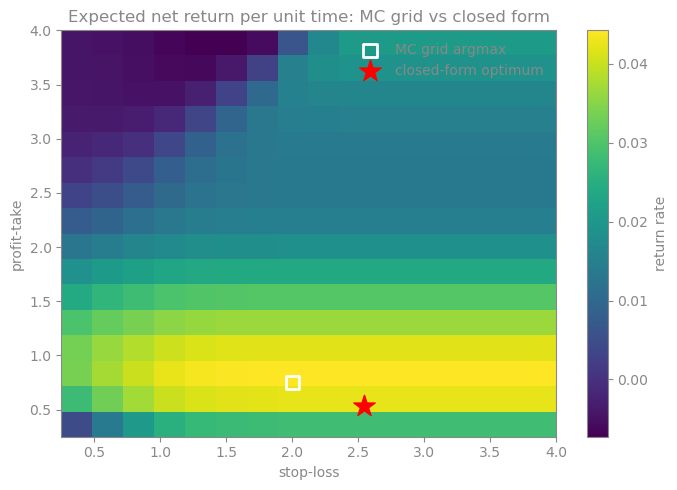

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(surface, origin="lower", aspect="auto", cmap="viridis",
               extent=[grid[0], grid[-1], grid[0], grid[-1]])
ax.scatter([grid[j]], [grid[i]], marker="s", s=90, edgecolor="white",
           facecolor="none", linewidth=2, label="MC grid argmax")
ax.scatter([rule["stop_loss"]], [rule["profit_take"]], marker="*", s=260,
           color="red", label="closed-form optimum")
ax.set_xlabel("stop-loss"); ax.set_ylabel("profit-take")
ax.set_title("Expected net return per unit time: MC grid vs closed form")
fig.colorbar(im, ax=ax, label="return rate"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## Takeaways

- **Prefer the closed-form OU rule over the Monte-Carlo grid whenever the OU model is
  used**: it reproduces the grid optimum within the grid's resolution, here many
  times faster, with no simulation noise. The objective is expected net return per
  unit time (the per-trade Sharpe is degenerate, maximized by an infinitesimal
  profit-take).
- It degrades **in step with** the grid when the process is off-model (no robustness
  to misspecification), so check the OU fit at decision time.

`optimal_ou_trading_rule` and `theta_from_half_life` come from
`RiskLabAI.backtest.ou_trading_rules`.